# Pipeline:

MTB genome
    
    ↓
Cas12a PAM detection
      
      ↓
Candidate guide generation
      
      ↓
Biological scoring
      
      ↓
Off-target analysis
      
      ↓
Machine learning ranking
      
      ↓
Biological Optimization
    
    • GC classification
    • Homopolymer detection
    • Poly-T detection
    • Shannon entropy
      
      ↓
Final Optimized Cas12a Guide Recommendations

# Initial Scoring System

In [1]:
!pip install biopython

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from Bio import SeqIO

import pandas as pd
import matplotlib.pyplot as plt

In [3]:
file = r"C:\Drive D\Desktop\IBM Data Science\CRISPR_MTB_Project\data\sequence.fasta"

record = SeqIO.read(file,"fasta")

genome = str(record.seq)

print(genome[:100])
print(len(genome))

TTGACCGATGACCCCGGTTCAGGCTTCACCACAGTGTGGAACGCGGTCGTCTCCGAACTTAACGGCGACCCTAAGGTTGACGACGGACCCAGCAGTGATG
4411532


### Clean sequence

In [4]:
genome = genome.upper()

genome = genome.replace("\n","")

print(genome[:50])

TTGACCGATGACCCCGGTTCAGGCTTCACCACAGTGTGGAACGCGGTCGT


### Find PAM sequences

In [5]:
def find_pam_sites(sequence):

    pam_sites=[]

    for i in range(len(sequence)-3):

        pam = sequence[i:i+4]

        if pam[:3] == "TTT":

            pam_sites.append(
                {
                    "position": i,
                    "pam": pam
                }
            )

    return pam_sites

In [6]:
pam_sites = find_pam_sites(genome)

len(pam_sites)

22900

## Extract 20 bp guide sequence

In [7]:
def extract_cas12a_targets(sequence,pam_sites):

    targets=[]

    for site in pam_sites:

        start = site["position"] + 4

        target = sequence[start:start+20]


        if len(target)==20:

            targets.append({

                "target":target,
                "pam":site["pam"],
                "position":start

            })


    return targets

In [8]:
targets = extract_cas12a_targets(
    genome,
    pam_sites
)

len(targets)

22900

In [9]:
print("PAM:", targets[0]["pam"])
print("Guide:", targets[0]["target"])

PAM: TTTG
Guide: CTCTGTTATCCGTGCCGAGC


### Calculate GC content

In [10]:
def gc_content(sequence):

    gc = (
        sequence.count("G")
        +
        sequence.count("C")
    ) / len(sequence)

    return round(gc, 2)

gc_content("ATGCGC")

0.67

In [11]:
for g in targets:

    g["length"] = len(g["target"])

    g["GC"] = gc_content(
        g["target"]
    )

targets[0]

{'target': 'CTCTGTTATCCGTGCCGAGC',
 'pam': 'TTTG',
 'position': 181,
 'length': 20,
 'GC': 0.6}

In [12]:
df = pd.DataFrame(targets)

#df.head()

### Create scoring system

In [13]:
def score_target(row):

    score = 0


    if row["length"] == 20:

        score += 1


    if 0.4 <= row["GC"] <= 0.6:

        score += 1


    return score

df["score"] = df.apply(
    score_target,
    axis=1
)

ranked = df.sort_values(
    "score",
    ascending=False
)

#ranked.head(10)

# (1) Off-Target Analysis

In [14]:
! pip install rapidfuzz Levenshtein

Defaulting to user installation because normal site-packages is not writeable


In [15]:
import numpy as np
from rapidfuzz import fuzz

def upgraded_similarity(seq1, seq2, method="crispr_weighted"):
    """
    Upgraded similarity function for comparing CRISPR guide targets.
    Supports ultra-fast standard ratios and biology-aware distance models.
    """
    # Standardize to uppercase strings
    s1, s2 = str(seq1).upper(), str(seq2).upper()
    
    # Check for exact length mismatches to avoid indexing errors
    if len(s1) != len(s2):
        # Fallback to fast standard text ratio if lengths differ
        return fuzz.ratio(s1, s2)
        
    if method == "fast":
        # RapidFuzz implementation of your original code (C++ speed)
        return fuzz.ratio(s1, s2)
        
    elif method == "crispr_weighted":
        # BIOLOGICAL UPGRADE: Cas12a is sensitive to mismatches near the PAM (positions 1-5).
        # Mismatches at the start (near PAM) drop the score heavily.
        # Mismatches at the end (away from PAM) are penalized less.
        total_score = 100.0
        
        for i in range(len(s1)):
            if s1[i] != s2[i]:
                if i < 5:
                    total_score -= 20.0  # Massive penalty for Seed-region mutation
                elif i < 12:
                    total_score -= 10.0  # Medium penalty for mid-region mutation
                else:
                    total_score -= 5.0   # Light penalty for distal-end mutation
                    
        return max(0.0, total_score)

# --- HOW TO RUN IT ON YOUR ENTIRE DATAFRAME ---
# Let's say you have a specific 'on_target_gene' sequence you want to compare against: 
target_gene_sequence = "TCACCCACACTGTGCCCATC"   # gene coding beta-actin (β-actin)

# Calculate the biological similarity score for every candidate guide row-by-row
df["off_target_similarity"] = df["target"].apply(
    lambda x: upgraded_similarity(x, target_gene_sequence, method="crispr_weighted")
)
# 3. Sort your data: High core score first, then LOWEST off-target similarity next
ranked = df.sort_values(
    by=["score", "off_target_similarity"],
    ascending=[False, True]  # True means lowest similarity (safest) comes first!
)

# 4. FORCE Python to print the result to your screen
ranked.head()

,target,pam,position,length,GC,score,off_target_similarity
0,CTCTGTTATCCGTGCCGAGC,TTTG,181,20,0.60,2,0.0
1,TCCAAAACGAAATCGAGCGC,TTTG,208,20,0.50,2,0.0
2,ATACGTTCGTTATCGGCGCC,TTTG,523,20,0.55,2,0.0
3,AGTGGGGGCTGATCACTGAC,TTTG,967,20,0.60,2,0.0
4,GTTGCCCAAAATCGGCCAAG,TTTC,1373,20,0.55,2,0.0


In [16]:
#ranked.tail()

## Visuzlization

### GC Distribution

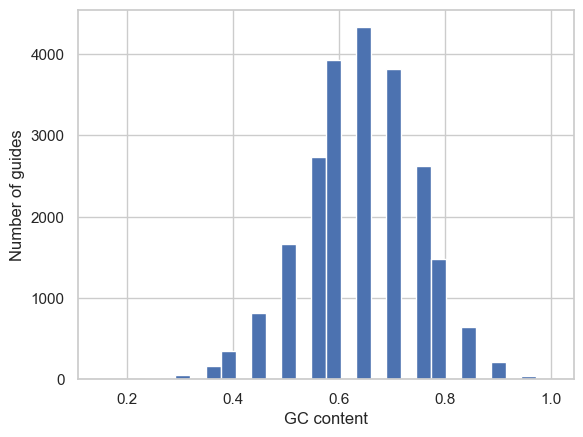

In [98]:
plt.hist(
    df["GC"],
    bins=30
)

plt.xlabel("GC content")

plt.ylabel("Number of guides")

plt.show()

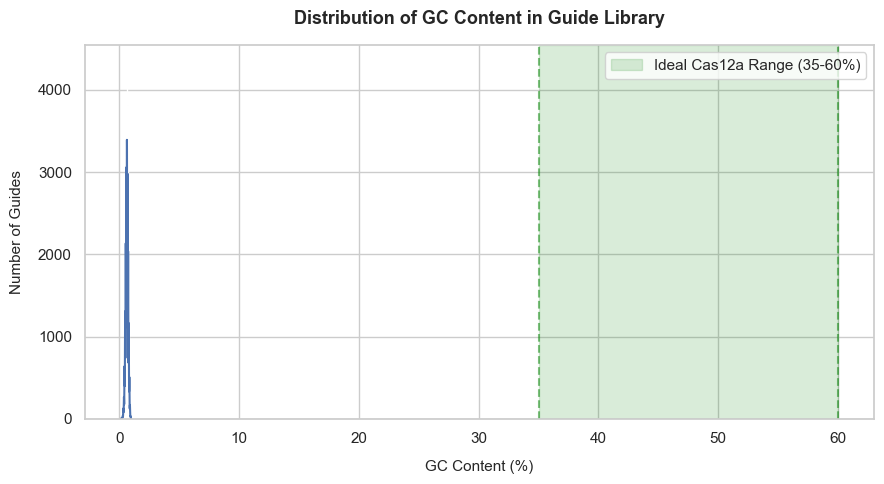

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual grid style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Create the histogram with a smooth density curve overlay
sns.histplot(
    data=df,
    x="GC",
    bins=30,
    kde=True,
    color="#4C72B0",       # Professional muted blue
    edgecolor="white"
)

# Highlight the ideal Cas12a GC content window (35% to 60%)
plt.axvspan(35, 60, color="green", alpha=0.15, label="Ideal Cas12a Range (35-60%)")

# Add dashed boundary lines for clarity
plt.axvline(35, color="green", linestyle="--", alpha=0.5, linewidth=1.5)
plt.axvline(60, color="green", linestyle="--", alpha=0.5, linewidth=1.5)

# Formatting
plt.xlabel("GC Content (%)", fontsize=11, labelpad=10)
plt.ylabel("Number of Guides", fontsize=11, labelpad=10)
plt.title("Distribution of GC Content in Guide Library", fontsize=13, pad=15, weight="bold")
plt.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


### Score Distribution

In [ ]:
df["score"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Score")

plt.ylabel("Number")

plt.show()

### Off-target Analysis Distribution

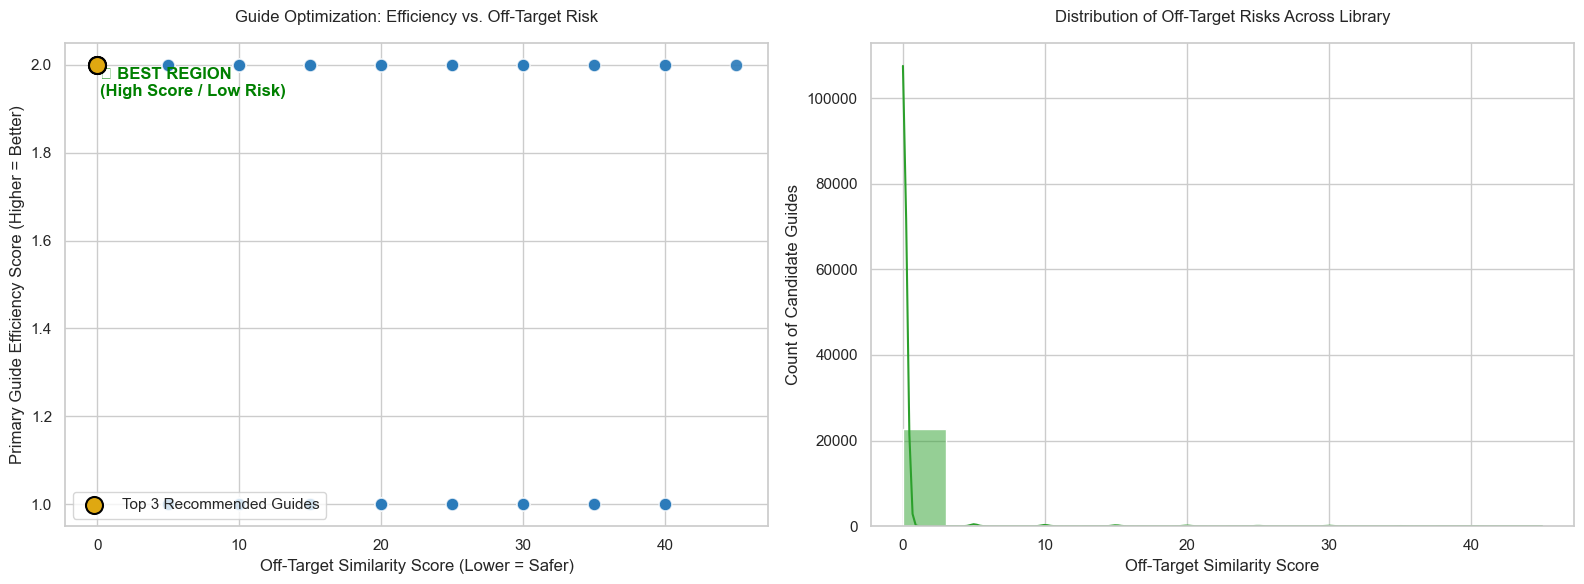

In [17]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Globally suppress all annoying deprecation or user warnings
warnings.filterwarnings("ignore")

# 2. Set up the plotting theme safely
sns.set_theme(style="whitegrid")

# Create the canvas (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------------------------
# PLOT 1: Scatter Plot (Explicitly passing ax1)
# ---------------------------------------------------------------------------
sns.scatterplot(
    data=ranked,
    x="off_target_similarity",
    y="score",
    alpha=0.7,
    edgecolor="w",
    s=80,
    color="#2b7bba",
    ax=ax1  # Correct strict keyword
)

# Highlight top 3 safely (only if dataframe actually has rows)
if len(ranked) > 0:
    top_3 = ranked.head(3)
    ax1.scatter(
        top_3["off_target_similarity"].tolist(),
        top_3["score"].tolist(),
        color="#dfa811",
        s=150,
        edgecolor="black",
        linewidth=1.5,
        label="Top 3 Recommended Guides",
        zorder=5  # Keeps dots on top layer
    )
    ax1.legend(loc="lower left")

ax1.set_title("Guide Optimization: Efficiency vs. Off-Target Risk", pad=15)
ax1.set_xlabel("Off-Target Similarity Score (Lower = Safer)")
ax1.set_ylabel("Primary Guide Efficiency Score (Higher = Better)")

# Add safe, static label positioning
ax1.text(0.05, 0.95, "⭐ BEST REGION\n(High Score / Low Risk)", 
         transform=ax1.transAxes, color="green", weight="bold", va="top")

# ---------------------------------------------------------------------------
# PLOT 2: Distribution Plot (Explicitly passing ax2)
# ---------------------------------------------------------------------------
sns.histplot(
    data=ranked,
    x="off_target_similarity",
    kde=True,
    color="#2ca02c",
    bins=15,
    ax=ax2  # Correct strict keyword
)

ax2.set_title("Distribution of Off-Target Risks Across Library", pad=15)
ax2.set_xlabel("Off-Target Similarity Score")
ax2.set_ylabel("Count of Candidate Guides")

# Layout adjustment
plt.tight_layout()
plt.show()


### Export results

In [18]:
ranked.to_csv(
    "Cas12a_MTB_ranked_candidates_v1.csv",
    index=False
)

# REALISTIC OFF-TARGET ANALYSIS UPGRADE

In [19]:

from Bio import SeqIO


def load_fasta(filename):

    record = SeqIO.read(
        filename,
        "fasta"
    )

    return str(record.seq).upper()


In [20]:
human_seq = load_fasta(
    r"C:\Drive D\Desktop\IBM Data Science\CRISPR_MTB_Project\data\human_reference.fasta"
)


ecoli_seq = load_fasta(
    r"C:\Drive D\Desktop\IBM Data Science\CRISPR_MTB_Project\data\E_coli_genome.fasta"
)


In [21]:
print(len(human_seq))
print(len(ecoli_seq))

1812
4641652


## Create a function to search similarity

In [22]:
from rapidfuzz import fuzz


def improved_offtarget_check(guide, genome):

    guide = guide.upper()
    genome = genome.upper()

    best_score = 0


    # search windows
    for i in range(
        len(genome)-len(guide)+1
    ):

        window = genome[
            i:i+len(guide)
        ]


        score = fuzz.ratio(
            guide,
            window
        )


        if score > best_score:

            best_score = score


    return best_score

In [23]:
test_guide = ranked.iloc[0]["target"] #taking the best guide

### Against human

In [24]:
human_seq = human_seq[:100000]
ecoli_seq = ecoli_seq[:100000]

In [25]:

human_score = improved_offtarget_check(
    test_guide,
    human_seq
)


print(human_score)

75.0


### Against E.coli

In [26]:

ecoli_score = improved_offtarget_check(
    test_guide,
    ecoli_seq
)


print(ecoli_score)


85.0


In [27]:
def calculate_offtargets(row):

    guide = row["target"]


    return pd.Series({

        "Human_similarity":
        improved_offtarget_check(
            guide,
            human_seq
        ),


        "Ecoli_similarity":
        improved_offtarget_check(
            guide,
            ecoli_seq
        )

    })

In [28]:
test_ranked = ranked.head(50)


offtarget_results = test_ranked.apply(
    calculate_offtargets,
    axis=1
)

In [29]:
offtarget_results.head()

,Human_similarity,Ecoli_similarity
0,75.0,85.0
1,75.0,85.0
2,75.0,85.0
3,80.0,80.0
4,75.0,80.0


## Combined Final Off-target Penalty Score

In [30]:
ranked_v2 = pd.concat(
    [
        test_ranked.reset_index(drop=True),
        offtarget_results.reset_index(drop=True)
    ],
    axis=1
)

In [31]:
ranked_v2.head()

,target,pam,position,length,GC,score,off_target_similarity,Human_similarity,Ecoli_similarity
0,CTCTGTTATCCGTGCCGAGC,TTTG,181,20,0.60,2,0.0,75.0,85.0
1,TCCAAAACGAAATCGAGCGC,TTTG,208,20,0.50,2,0.0,75.0,85.0
2,ATACGTTCGTTATCGGCGCC,TTTG,523,20,0.55,2,0.0,75.0,85.0
3,AGTGGGGGCTGATCACTGAC,TTTG,967,20,0.60,2,0.0,80.0,80.0
4,GTTGCCCAAAATCGGCCAAG,TTTC,1373,20,0.55,2,0.0,75.0,80.0


In [32]:
def final_score(row):

    return (
        row["score"]
        -
        row["Human_similarity"]/100
        -
        row["Ecoli_similarity"]/100
    )

In [33]:
ranked_v2["final_score"] = ranked_v2.apply(
    final_score,
    axis=1
)

In [34]:
final_ranked = ranked_v2.sort_values(
    by="final_score",
    ascending=False
)

In [35]:
final_ranked.head(10)

,target,pam,position,length,GC,score,off_target_similarity,Human_similarity,Ecoli_similarity,final_score
12,TCCTGGAAGCGTTTTAGTTT,TTTC,2275,20,0.40,2,0.0,70.0,80.0,0.50
6,TTCGTCGTTTGTTCTTGGAA,TTTC,1799,20,0.40,2,0.0,70.0,80.0,0.50
15,TGGCCGATTGTTGTCCGATA,TTTC,2296,20,0.50,2,0.0,70.0,80.0,0.50
48,AGTGTCCCCTTAGTGTGCTT,TTTC,14166,20,0.50,2,0.0,70.0,80.0,0.50
22,GTTGGGCCTAACGGTTATGG,TTTT,3363,20,0.55,2,0.0,70.0,85.0,0.45
21,TGTTGGGCCTAACGGTTATG,TTTT,3362,20,0.50,2,0.0,70.0,85.0,0.45
20,GGGTTTACGACTGCGGGTAA,TTTC,3113,20,0.55,2,0.0,70.0,85.0,0.45
23,TTGGGCCTAACGGTTATGGT,TTTG,3364,20,0.50,2,0.0,70.0,85.0,0.45
18,TGCGGGTGCCGATGATGTTG,TTTC,2977,20,0.60,2,0.0,70.0,85.0,0.45
11,CGGATTCGACTACGAGGTTT,TTTC,2221,20,0.50,2,0.0,75.0,80.0,0.45


### Top 20 guides from off-target analysis

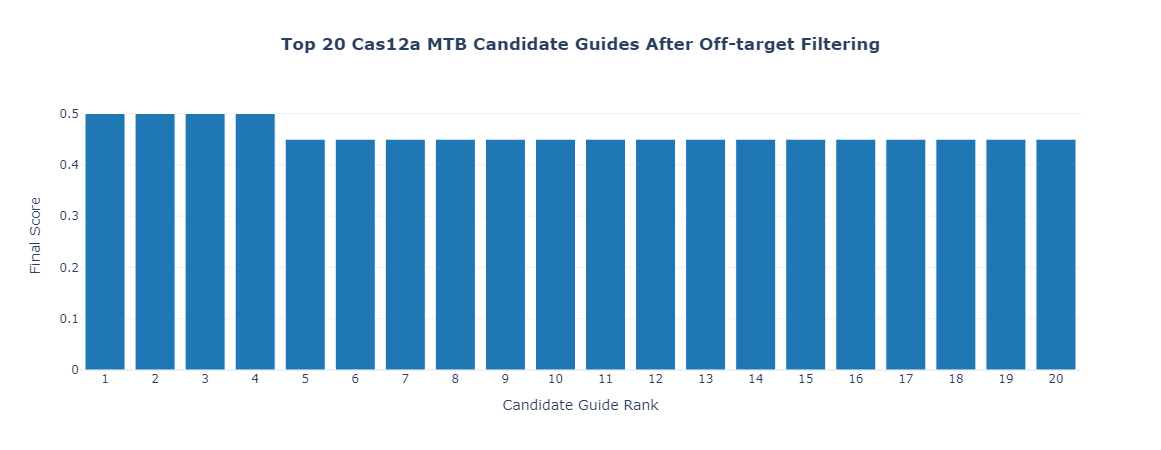

In [92]:
import plotly.express as px

# Clone the top 20 and explicitly set a 1-indexed Rank column
top20_interactive = final_ranked.head(20).copy()
top20_interactive["Rank"] = range(1, 21)

# Build interactive bar plot
fig = px.bar(
    top20_interactive,
    x="Rank",
    y="final_score",
    # Add any extra metrics you want to see instantly on mouse-hover:
    hover_data=["target", "GC", "Human_similarity"] if "GC" in final_ranked.columns else ["target"], 
    title="<b>Top 20 Cas12a MTB Candidate Guides After Off-target Filtering</b>",
    labels={"Rank": "Candidate Guide Rank", "final_score": "Final Score"}
)

# Apply sleek styling adjustments
fig.update_traces(
    marker_color="#1f77b4", 
    marker_line_color="white", 
    marker_line_width=1
)

fig.update_layout(
    width=850,
    height=450,
    xaxis=dict(tickmode="linear", tick0=1, dtick=1), # Forces all ticks 1 through 20 to label cleanly
    template="plotly_white",
    title_x=0.5                                      # Center-aligns the title
)

fig.show()


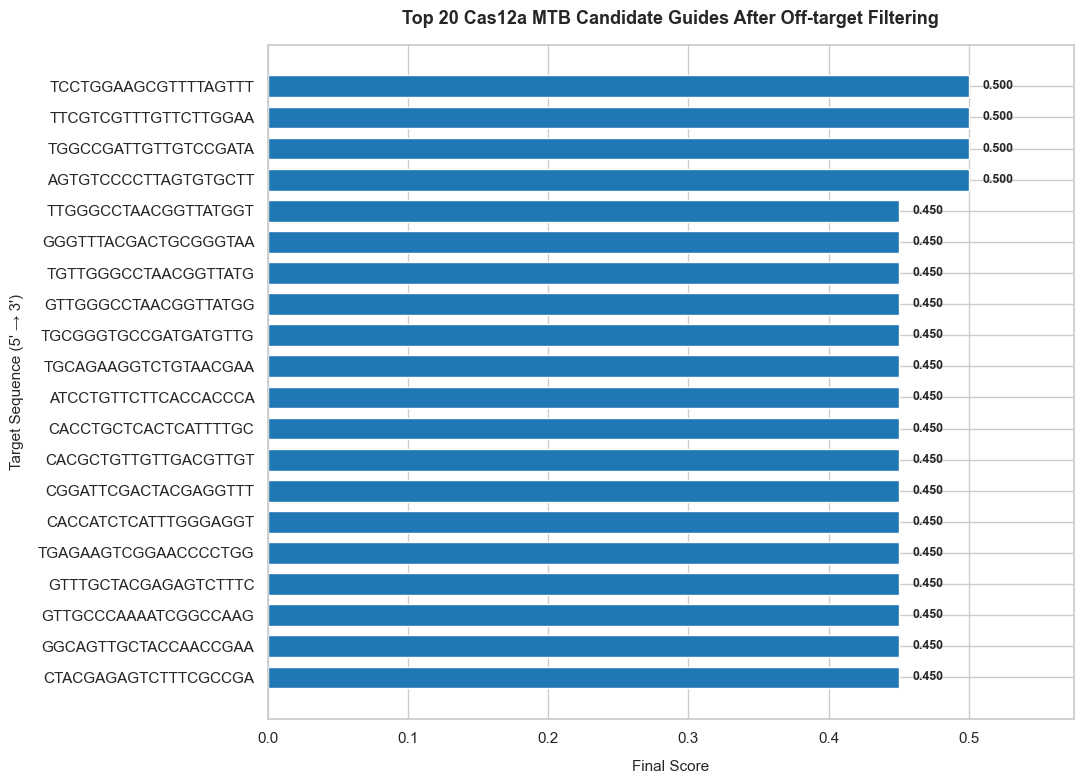

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort so the highest-scoring candidate appears at the very top of the plot
top20_sorted = final_ranked.head(20).sort_values(by="final_score", ascending=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 8)) # Taller canvas to clearly fit sequence strings

# Generate the horizontal bars
bars = plt.barh(
    top20_sorted["target"],          # Directly lists the guide sequence string on the axis
    top20_sorted["final_score"],
    color="#1f77b4",                 # Clean, standard data science blue
    height=0.7
)

# Overlay the exact final score value right next to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,                # Muted offset to the right of the bar edge
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",              # Formatted cleanly to 3 decimal places
        va="center", 
        ha="left", 
        fontsize=9, 
        weight="semibold"
    )

# Axis labels and titles
plt.xlabel("Final Score", fontsize=11, labelpad=10)
plt.ylabel("Target Sequence (5' → 3')", fontsize=11, labelpad=10)
plt.title("Top 20 Cas12a MTB Candidate Guides After Off-target Filtering", fontsize=13, pad=15, weight="bold")

# Add a little padding to the right edge so the text labels don't get cut off
plt.xlim(0, max(top20_sorted["final_score"]) * 1.15)

plt.tight_layout()
plt.show()


In [36]:
import sys
print(sys.executable)

C:\Users\USER\.conda\envs\Oscar_env\python.exe


In [37]:
!{sys.executable} -m pip install openpyxl

In [38]:
final_ranked.to_excel(
    "Cas12a_MTB_final_ranked_targets.xlsx",
    index=False
)

# (2) ML-based guide ranking

In [39]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

In [40]:
X = final_ranked[
    [
        "GC",
        "score",
        "Human_similarity",
        "Ecoli_similarity"
    ]
]

In [41]:
final_ranked["label"] = np.where(
    final_ranked["final_score"] >= 
    final_ranked["final_score"].median(),
    1,
    0
)

In [42]:
final_ranked["label"].value_counts()

label
1    34
0    16
Name: count, dtype: int64

In [43]:
y = final_ranked["label"]

### Create Random Forest model

In [44]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

### 5-fold cross validation

In [45]:
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

In [46]:
print(cv_scores)

print(
    "Average accuracy:",
    cv_scores.mean()
)

[1.  1.  1.  0.9 0.9]
Average accuracy: 0.96


### Train final model on all data

In [47]:
model.fit(
    X,
    y
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [48]:
final_ranked["ML_probability"] = (
    model.predict_proba(X)[:,1]
)

In [49]:
ml_ranked = final_ranked.sort_values(
    by="ML_probability",
    ascending=False
)

In [50]:
ml_ranked.head(10)

,target,pam,position,length,GC,score,off_target_similarity,Human_similarity,Ecoli_similarity,final_score,label,ML_probability
48,AGTGTCCCCTTAGTGTGCTT,TTTC,14166,20,0.50,2,0.0,70.0,80.0,0.50,1,1.0
15,TGGCCGATTGTTGTCCGATA,TTTC,2296,20,0.50,2,0.0,70.0,80.0,0.50,1,1.0
33,CACGCTGTTGTTGACGTTGT,TTTC,6861,20,0.50,2,0.0,75.0,80.0,0.45,1,1.0
10,CTACGAGAGTCTTTCGCCGA,TTTG,2102,20,0.55,2,0.0,75.0,80.0,0.45,1,1.0
22,GTTGGGCCTAACGGTTATGG,TTTT,3363,20,0.55,2,0.0,70.0,85.0,0.45,1,1.0
21,TGTTGGGCCTAACGGTTATG,TTTT,3362,20,0.50,2,0.0,70.0,85.0,0.45,1,1.0
20,GGGTTTACGACTGCGGGTAA,TTTC,3113,20,0.55,2,0.0,70.0,85.0,0.45,1,1.0
23,TTGGGCCTAACGGTTATGGT,TTTG,3364,20,0.50,2,0.0,70.0,85.0,0.45,1,1.0
11,CGGATTCGACTACGAGGTTT,TTTC,2221,20,0.50,2,0.0,75.0,80.0,0.45,1,1.0
28,CACCATCTCATTTGGGAGGT,TTTA,5365,20,0.50,2,0.0,75.0,80.0,0.45,1,1.0


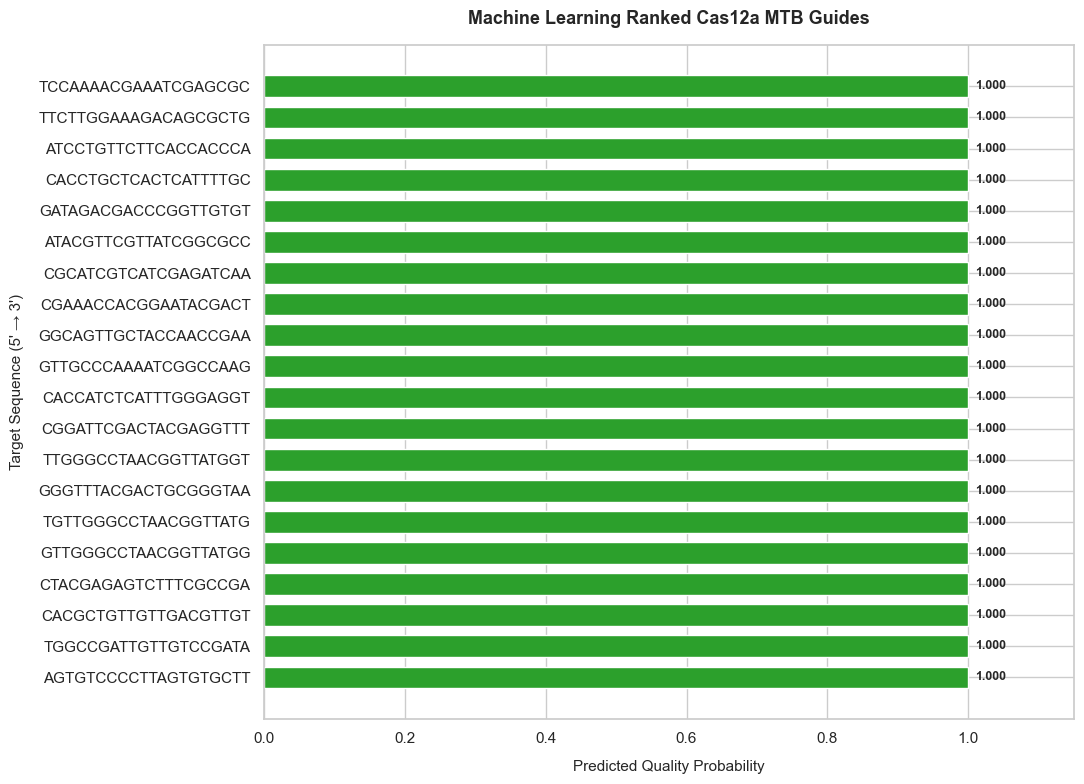

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically find how many rows are actually available (up to 20)
num_bars = min(20, len(ml_ranked))
# Sort so the highest probability candidate appears at the very top of the plot
top_sorted = ml_ranked.head(num_bars).sort_values(by="ML_probability", ascending=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 8)) # Taller canvas to clearly fit sequence strings

# Generate the horizontal bars
bars = plt.barh(
    top_sorted["target"],          # Directly lists the guide sequence string on the axis
    top_sorted["ML_probability"],
    color="#2ca02c",                 # Clean "machine learning green"
    height=0.7
)

# Overlay the exact probability value right next to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,                # Muted offset to the right of the bar edge
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",              # Formatted cleanly to 3 decimal places
        va="center", 
        ha="left", 
        fontsize=9, 
        weight="semibold"
    )

# Axis labels and titles
plt.xlabel("Predicted Quality Probability", fontsize=11, labelpad=10)
plt.ylabel("Target Sequence (5' → 3')", fontsize=11, labelpad=10)
plt.title("Machine Learning Ranked Cas12a MTB Guides", fontsize=13, pad=15, weight="bold")

# Add a little padding to the right edge so the text labels don't get cut off
plt.xlim(0, 1.15 if max(top_sorted["ML_probability"]) * 1.15 > 1.0 else 1.15)

plt.tight_layout()
plt.show()


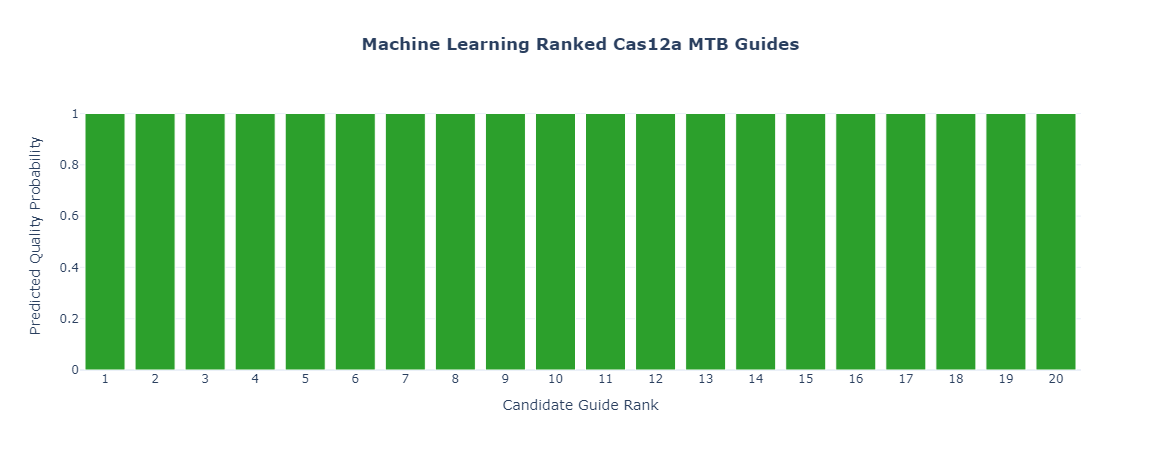

In [95]:
import plotly.express as px

# Grab available rows up to 20 and explicitly set a 1-indexed Rank column
num_bars = min(20, len(ml_ranked))
top_interactive = ml_ranked.head(num_bars).copy()
top_interactive["Rank"] = range(1, num_bars + 1)

# Build interactive bar plot
fig = px.bar(
    top_interactive,
    x="Rank",
    y="ML_probability",
    # Add any extra metrics you want to see instantly on mouse-hover:
    hover_data=["target", "Entropy", "Biological_score"] if "Entropy" in ml_ranked.columns else ["target"], 
    title="<b>Machine Learning Ranked Cas12a MTB Guides</b>",
    labels={"Rank": "Candidate Guide Rank", "ML_probability": "Predicted Quality Probability"}
)

# Apply sleek styling adjustments
fig.update_traces(
    marker_color="#2ca02c", 
    marker_line_color="white", 
    marker_line_width=1
)

fig.update_layout(
    width=850,
    height=450,
    xaxis=dict(tickmode="linear", tick0=1, dtick=1), # Forces all ticks to label cleanly without decimals
    template="plotly_white",
    title_x=0.5                                      # Center-aligns the title
)

fig.show()


### Importance determination

In [52]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
2,Human_similarity,0.791955
3,Ecoli_similarity,0.133842
0,GC,0.074203
1,score,0.000000


In [53]:
ml_ranked.to_excel(
    "Cas12a_MTB_ML_ranked_targets.xlsx",
    index=False
)

# (3) Biological Optimization

    • GC classification
    • Homopolymer detection
    • Poly-T detection
    • Shannon entropy

In [54]:
optimized = ml_ranked.copy()

In [55]:
from collections import Counter
import math

In [56]:
#GC Classification

def gc_status(gc):

    if 0.40 <= gc <= 0.60:
        return "Optimal"

    elif 0.30 <= gc < 0.40 or 0.60 < gc <= 0.70:
        return "Acceptable"

    else:
        return "Poor"

In [57]:
optimized["GC_status"] = optimized["GC"].apply(gc_status)

In [58]:
#Longest homopolymer

def longest_repeat(sequence):

    longest = 1
    current = 1

    for i in range(1, len(sequence)):

        if sequence[i] == sequence[i-1]:
            current += 1
            longest = max(longest, current)
        else:
            current = 1

    return longest

In [59]:
optimized["Longest_repeat"] = (
    optimized["target"]
    .apply(longest_repeat)
)

In [60]:
#Poly-T detection

def has_polyT(sequence):

    return "TTTT" in sequence

In [61]:
optimized["PolyT"] = (
    optimized["target"]
    .apply(has_polyT)
)

In [62]:
#Shannon Entropy

def shannon_entropy(sequence):

    counts = Counter(sequence)

    entropy = 0

    for count in counts.values():

        p = count / len(sequence)

        entropy -= p * math.log2(p)

    return entropy

In [63]:
optimized["Entropy"] = (
    optimized["target"]
    .apply(shannon_entropy)
)

In [64]:
#remove duplicates

optimized = optimized.drop_duplicates(
    subset="target"
)

In [65]:
# Biological optimization score

def biological_score(row):

    score = row["ML_probability"] * 100

    # GC content
    if row["GC_status"] == "Optimal":
        score += 10
    elif row["GC_status"] == "Poor":
        score -= 10

    # Homopolymers
    if row["Longest_repeat"] >= 4:
        score -= 10

    # Poly-T
    if row["PolyT"]:
        score -= 10

    # Shannon entropy
    if row["Entropy"] >= 1.5:
        score += 10
    else:
        score -= 10

    return score

In [66]:
optimized["Biological_score"] = (
    optimized.apply(
        biological_score,
        axis=1
    )
)

In [68]:
#Final ranking

final_guides = optimized.sort_values(
    by="Biological_score",
    ascending=False
)

In [71]:
final_guides_modified = final_guides[
    [
        "target",
        "GC",
        "GC_status",
        "Human_similarity",
        "Ecoli_similarity",
        "Longest_repeat",
        "PolyT",
        "Entropy",
        "ML_probability",
        "Biological_score"
    ]
]

final_guides_modified.head(10)

,target,GC,GC_status,Human_similarity,Ecoli_similarity,Longest_repeat,PolyT,Entropy,ML_probability,Biological_score
15,TGGCCGATTGTTGTCCGATA,0.50,Optimal,70.0,80.0,2,False,1.926121,1.0,120.0
33,CACGCTGTTGTTGACGTTGT,0.50,Optimal,75.0,80.0,2,False,1.846439,1.0,120.0
17,GGCAGTTGCTACCAACCGAA,0.55,Optimal,75.0,80.0,2,False,1.952724,1.0,120.0
10,CTACGAGAGTCTTTCGCCGA,0.55,Optimal,75.0,80.0,3,False,1.985475,1.0,120.0
22,GTTGGGCCTAACGGTTATGG,0.55,Optimal,70.0,85.0,3,False,1.870951,1.0,120.0
21,TGTTGGGCCTAACGGTTATG,0.50,Optimal,70.0,85.0,3,False,1.881291,1.0,120.0
20,GGGTTTACGACTGCGGGTAA,0.55,Optimal,70.0,85.0,3,False,1.903702,1.0,120.0
23,TTGGGCCTAACGGTTATGGT,0.50,Optimal,70.0,85.0,3,False,1.881291,1.0,120.0
11,CGGATTCGACTACGAGGTTT,0.50,Optimal,75.0,80.0,3,False,1.970951,1.0,120.0
28,CACCATCTCATTTGGGAGGT,0.50,Optimal,75.0,80.0,3,False,1.985475,1.0,120.0


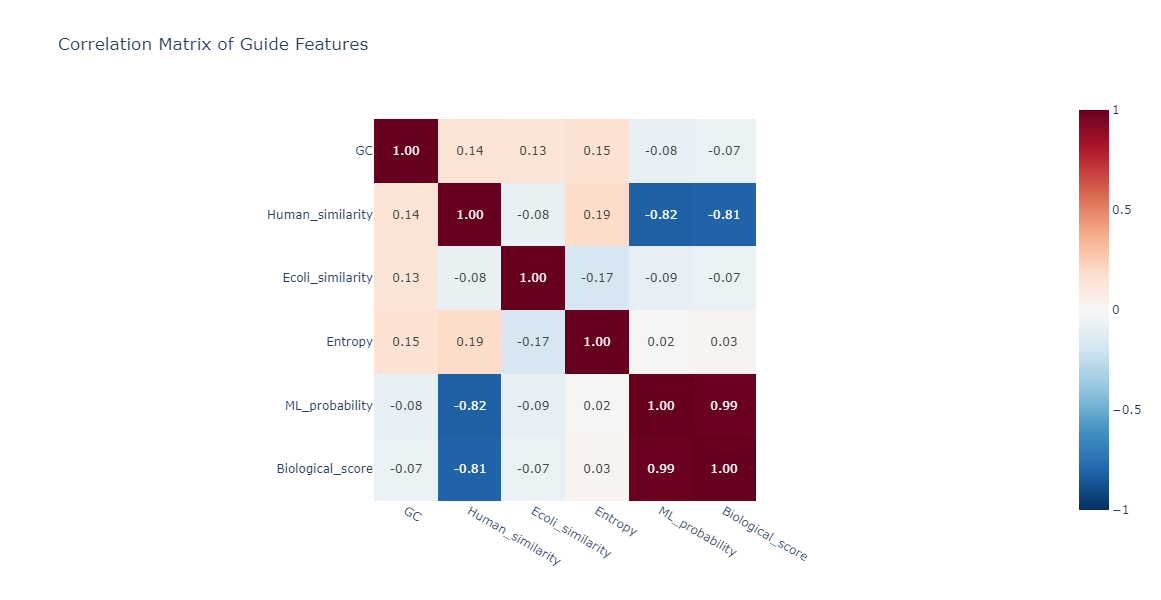

In [76]:
#Correlation Heatmap

import plotly.express as px

# 1. Calculate correlation matrix
features = [
    "GC", "Human_similarity", "Ecoli_similarity", 
    "Entropy", "ML_probability", "Biological_score"
]
corr = final_guides[features].corr()

# 2. Create interactive heatmap
fig = px.imshow(
    corr,
    text_auto=".2f",                # Automatically overlays exact numbers rounded to 2 decimals
    color_continuous_scale="RdBu_r",# Beautiful Red-Blue diverging scale (red=pos, blue=neg)
    zmin=-1, zmax=1,                # Locks limits to -1 and 1
    title="Correlation Matrix of Guide Features"
)

# 3. Adjust layout dimensions
fig.update_layout(width=600, height=600)
fig.show()


#### Distribution of Biological Score

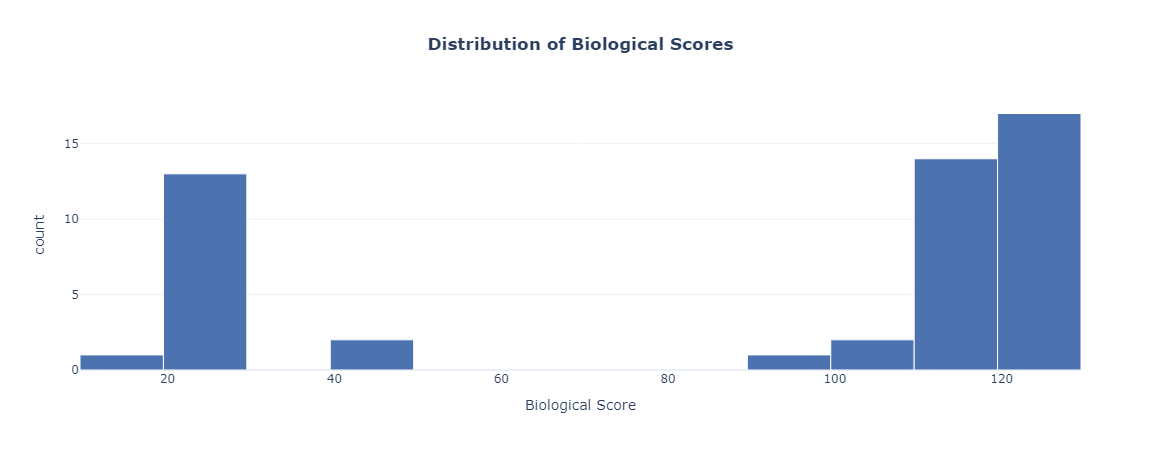

In [78]:
import plotly.express as px

# Create interactive histogram
fig = px.histogram(
    final_guides, 
    x="Biological_score", 
    nbins=20,
    title="<b>Distribution of Biological Scores</b>",
    labels={"Biological_score": "Biological Score", "count": "Number of Guides"},
    color_discrete_sequence=["#4C72B0"] # Matching professional blue color
)

# Add a subtle border to the bars for visual separation
fig.update_traces(marker_line_width=1, marker_line_color="white")

# Adjust layout size and title alignment
fig.update_layout(
    width=750, 
    height=450,
    title_x=0.5, # Centers the title
    template="plotly_white"
)

fig.show()


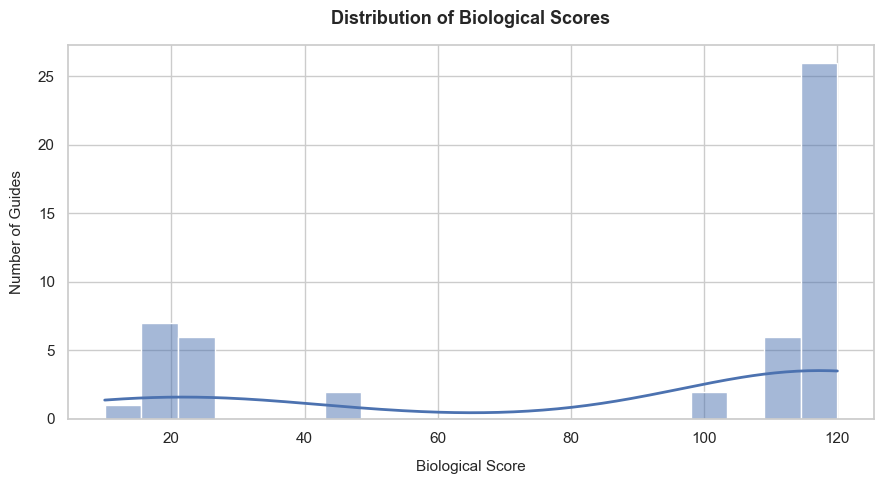

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

# Create the histogram with a smooth density curve overlay
sns.histplot(
    data=final_guides,
    x="Biological_score",
    bins=20,
    kde=True,                  # Adds the smooth trend line
    color="#4C72B0",           # Professional muted blue
    edgecolor="white",         # Cleaner look than harsh black lines
    line_kws={"linewidth": 2}   # Makes the trend line thicker
)

# Label adjustments
plt.xlabel("Biological Score", fontsize=11, labelpad=10)
plt.ylabel("Number of Guides", fontsize=11, labelpad=10)
plt.title("Distribution of Biological Scores", fontsize=13, pad=15, weight="bold")

plt.tight_layout()
plt.show()


#### Top 20 Guides

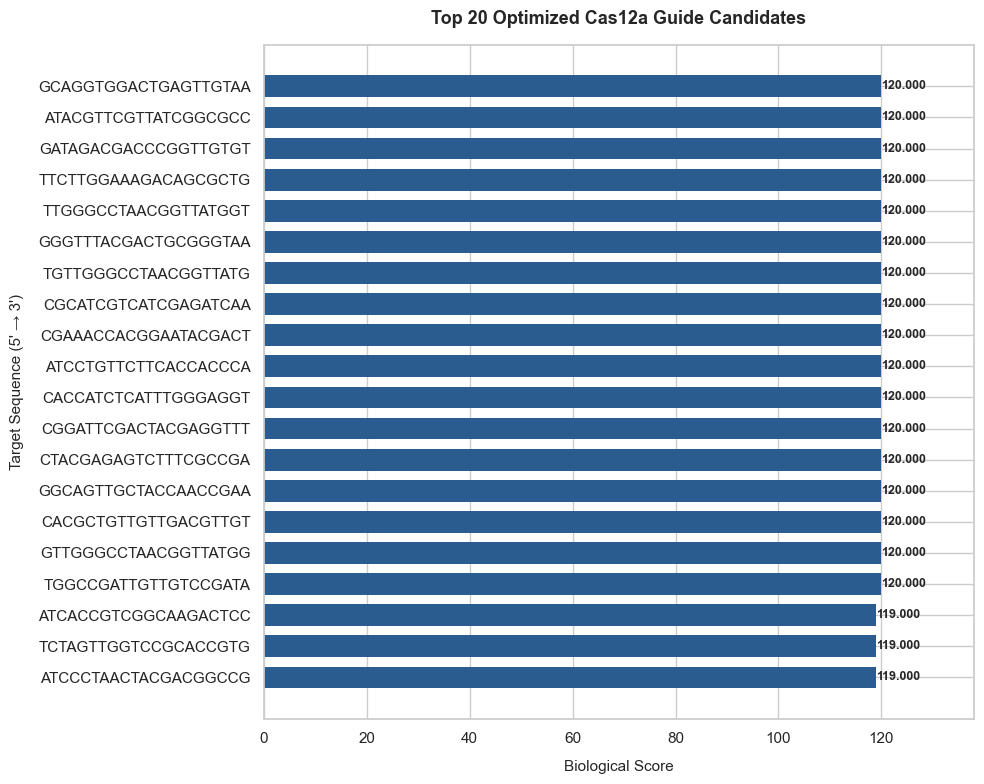

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort to ensure the absolute highest score is at the very top of the horizontal chart
top20_sorted = final_guides_modified.head(20).sort_values(by="Biological_score", ascending=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8)) # Taller canvas to fit sequence text cleanly

# Create horizontal bars
bars = plt.barh(
    top20_sorted["target"],          # Use actual guide sequence as labels
    top20_sorted["Biological_score"],
    color="#2b5c8f",
    edgecolor="none",
    height=0.7
)

# Overlay the exact score value text at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,                # Slight offset to the right of the bar edge
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",             # Format to 3 decimal places
        va="center", 
        ha="left", 
        fontsize=9, 
        weight="semibold"
    )

# Formatting
plt.xlabel("Biological Score", fontsize=11, labelpad=10)
plt.ylabel("Target Sequence (5' → 3')", fontsize=11, labelpad=10)
plt.title("Top 20 Optimized Cas12a Guide Candidates", fontsize=13, pad=15, weight="bold")

# Give the x-axis a bit of extra room for the text labels
plt.xlim(0, max(top20_sorted["Biological_score"]) * 1.15)

plt.tight_layout()
plt.show()


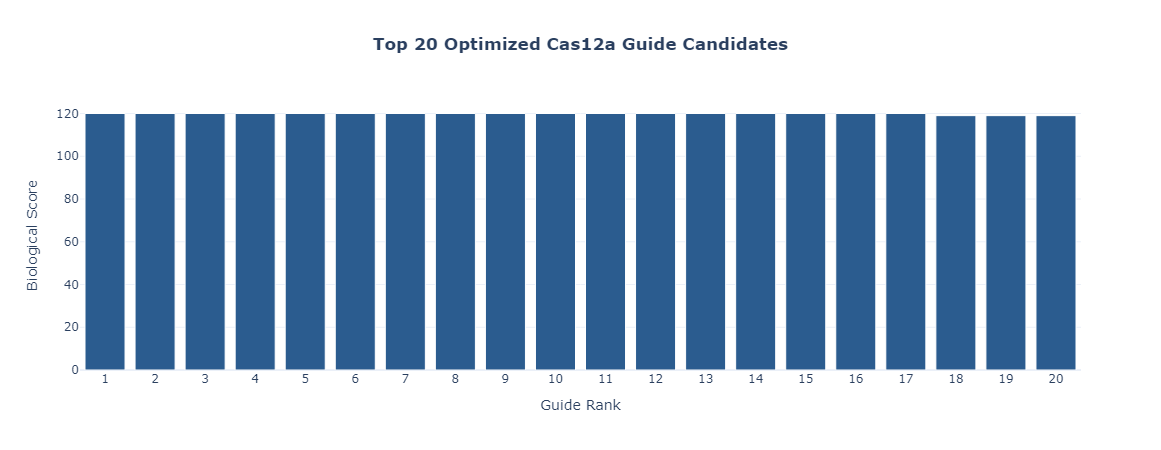

In [84]:
import plotly.express as px

# Grab the top 20 rows and reset index to act as the Rank
top20 = final_guides_modified.head(20).copy()
top20["Rank"] = range(1, 21)

# Create interactive vertical bar chart
fig = px.bar(
    top20,
    x="Rank",
    y="Biological_score",
    # hover_data appends these column values onto your mouse tooltip box automatically
    hover_data=["target", "GC", "ML_probability"], 
    title="<b>Top 20 Optimized Cas12a Guide Candidates</b>",
    labels={"Rank": "Guide Rank", "Biological_score": "Biological Score"}
)

# Visual styling
fig.update_traces(
    marker_color="#2b5c8f", 
    marker_line_color="white", 
    marker_line_width=1
)

fig.update_layout(
    width=850,
    height=450,
    xaxis=dict(tickmode="linear", tick0=1, dtick=1), # Forces every integer 1-20 to show up
    template="plotly_white",
    title_x=0.5
)

fig.show()


In [85]:
final_guides_modified.to_excel(
    "Final_Optimized_Cas12a_Guides.xlsx",
    index=False
)

In [86]:
import os
os.path.exists("Final_Optimized_Cas12a_Guides.xlsx")

True

In [87]:
import os

print(os.getcwd())

C:\Drive D\Desktop\IBM Data Science\CRISPR_MTB_Project\Notebook


In [88]:
os.listdir()

['.ipynb_checkpoints',
 '.jupyter',
 '.virtual_documents',
 'AI-assisted MTB detection_Intro.ipynb',
 'anaconda_projects',
 'Cas12a_MTB_final_ranked_targets.xlsx',
 'Cas12a_MTB_ML_ranked_targets.xlsx',
 'Cas12a_MTB_ranked_candidates_v1.csv',
 'Cas12a_MTB_Target_Design_v1.5.ipynb',
 'Cas12a_MTB_Target_Design_v1.ipynb',
 'Cas12a_MTB_Target_Design_v2.ipynb',
 'Cas12a_MTB_Target_Design_v3.ipynb',
 'Cas12a_MTB_Target_Design_v3.ipynb - Colab.pdf',
 'Final_Optimized_Cas12a_Guides.xlsx']

In [89]:
final_guides.to_excel(
    r"C:\Drive D\Desktop\IBM Data Science\CRISPR_MTB_Project\Results\Final_Optimized_Cas12a_Guides.xlsx",
    index=False
)

print("Done")

Done


In [90]:
import pandas as pd

test = pd.read_excel("Final_Optimized_Cas12a_Guides.xlsx")

print(test.head())

                 target    GC GC_status  Human_similarity  Ecoli_similarity  \
0  TGGCCGATTGTTGTCCGATA  0.50   Optimal                70                80   
1  CACGCTGTTGTTGACGTTGT  0.50   Optimal                75                80   
2  GGCAGTTGCTACCAACCGAA  0.55   Optimal                75                80   
3  CTACGAGAGTCTTTCGCCGA  0.55   Optimal                75                80   
4  GTTGGGCCTAACGGTTATGG  0.55   Optimal                70                85   

   Longest_repeat  PolyT   Entropy  ML_probability  Biological_score  
0               2  False  1.926121             1.0               120  
1               2  False  1.846439             1.0               120  
2               2  False  1.952724             1.0               120  
3               3  False  1.985475             1.0               120  
4               3  False  1.870951             1.0               120  


In [91]:
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")

output = os.path.join(desktop, "Final_Optimized_Cas12a_Guides.xlsx")

final_guides.to_excel(output, index=False)

print(output)

C:\Users\USER\Desktop\Final_Optimized_Cas12a_Guides.xlsx
